# Task 2: Exploratory Data Analysis (EDA)
## Ethiopia Financial Inclusion Forecasting System

**Objective**: Analyze patterns and factors influencing financial inclusion in Ethiopia.

**Date**: 28 Jan - 03 Feb 2026

**Team**: Selam Analytics


## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import sys
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple

# Setup visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('task_2_execution.log'),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

logger.info("="*80)
logger.info("TASK 2: Exploratory Data Analysis")
logger.info(f"Execution started: {datetime.now()}")
logger.info("="*80)

2026-02-02 11:37:38,551 - __main__ - INFO - ================================================================================
2026-02-02 11:37:38,551 - __main__ - INFO - TASK 2: Exploratory Data Analysis
2026-02-02 11:37:38,551 - __main__ - INFO - Execution started: 2026-02-02 11:37:38.551840
2026-02-02 11:37:38,551 - __main__ - INFO - ================================================================================


In [2]:
# Add Scripts Folder to Path
import os
import sys

cwd = os.getcwd()
scripts_path = os.path.join(cwd,'..', 'src')
scripts_abs_path = os.path.abspath(scripts_path)

if scripts_abs_path not in sys.path and os.path.isdir(scripts_abs_path):
    sys.path.append(scripts_abs_path)
    print('scripts path added to sys.path')
    logger.info(f"Added scripts path to sys.path: {scripts_abs_path}")

else:
    print('scripts path already in sys.path or does not exist')
    logger.info(f"Scripts path already in sys.path or does not exist: {scripts_abs_path}")

scripts path added to sys.path
2026-02-02 11:37:38,575 - __main__ - INFO - Added scripts path to sys.path: c:\GitHub\Forecasting-Financial-Inclusion-in-Ethiopia\src


## 2. Load Processed Data

In [3]:
# Load enriched data from Task 1
try:
    df = pd.read_csv('../data/processed/ethiopia_fi_unified_data_enriched.csv')
    logger.info(f"Loaded enriched data: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    logger.warning("Enriched data not found, loading original data")
    df = pd.read_excel('../data/raw/ethiopia_fi_unified_data.xlsx', sheet_name='ethiopia_fi_unified_data')
    logger.info(f"Loaded original data: {df.shape[0]} rows, {df.shape[1]} columns")

# Parse dates
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
df['collection_date'] = pd.to_datetime(df['collection_date'], errors='coerce')

2026-02-02 11:37:38,608 - __main__ - INFO - Loaded enriched data: 45 rows, 34 columns


C:\Users\henokt\AppData\Local\Temp\ipykernel_41076\4130708116.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['collection_date'] = pd.to_datetime(df['collection_date'], errors='coerce')


## 3. Data Overview and Quality Assessment

In [4]:
from comprehensive_analyzer import DataQualityAnalyzer

# Run quality assessment
quality_analyzer = DataQualityAnalyzer(logger)
completeness = quality_analyzer.assess_completeness(df)
confidence_dist = quality_analyzer.assess_confidence(df)
data_gaps = quality_analyzer.identify_gaps(df)

2026-02-02 11:37:38,644 - __main__ - INFO - 
Assessing data completeness
2026-02-02 11:37:38,648 - __main__ - INFO - Total cells: 1530
2026-02-02 11:37:38,650 - __main__ - INFO - Missing cells: 650
2026-02-02 11:37:38,650 - __main__ - INFO - Completeness: 57.52%
2026-02-02 11:37:38,650 - __main__ - INFO - 
Assessing confidence levels
2026-02-02 11:37:38,650 - __main__ - INFO - 
Confidence Distribution:
confidence
high      41
medium     4
Name: count, dtype: int64
2026-02-02 11:37:38,650 - __main__ - INFO - 
Identifying data gaps
2026-02-02 11:37:38,679 - __main__ - INFO - 
Indicators with missing recent data: 0


## 4. Access Indicator Analysis

In [5]:
from comprehensive_analyzer import AccessAnalyzer

# Run Access analysis
access_analyzer = AccessAnalyzer(logger)
ownership_data = access_analyzer.analyze_account_ownership(df)
gender_gap = access_analyzer.analyze_gender_gap(df)
mm_data = access_analyzer.analyze_mobile_money(df)

2026-02-02 11:37:38,692 - __main__ - INFO - 
2026-02-02 11:37:38,692 - __main__ - INFO - ACCOUNT OWNERSHIP ANALYSIS
2026-02-02 11:37:38,695 - __main__ - INFO - ============================================================
2026-02-02 11:37:38,700 - __main__ - INFO - 
Account Ownership Trajectory (2011-2024):
2026-02-02 11:37:38,706 - __main__ - INFO -   observation_date  value_numeric  gender
0       2014-12-31           22.0     all
1       2017-12-31           35.0     all
2       2021-12-31           46.0     all
3       2021-12-31           56.0    male
4       2021-12-31           36.0  female
5       2024-11-29           49.0     all
2026-02-02 11:37:38,712 - __main__ - INFO - 
Growth Rates:
2026-02-02 11:37:38,713 - __main__ - INFO -   observation_date  value_numeric  growth_pp  growth_pct
0       2014-12-31           22.0        NaN         NaN
1       2017-12-31           35.0       13.0   59.090909
2       2021-12-31           46.0       11.0   31.428571
5       2024-11-29     

## 5. Usage Indicator Analysis

In [6]:
from comprehensive_analyzer import UsageAnalyzer

# Run Usage analysis
usage_analyzer = UsageAnalyzer(logger)
payment_adoption = usage_analyzer.analyze_payment_adoption(df)
p2p_data = usage_analyzer.analyze_transaction_growth(df)
usage_gap = usage_analyzer.calculate_usage_gap(df)

2026-02-02 11:37:38,758 - __main__ - INFO - 
2026-02-02 11:37:38,760 - __main__ - INFO - DIGITAL PAYMENT ADOPTION ANALYSIS
2026-02-02 11:37:38,761 - __main__ - INFO - ============================================================
2026-02-02 11:37:38,764 - __main__ - INFO - P2P Transaction Count: 128300000.00 (as of 2025-07-07)
2026-02-02 11:37:38,768 - __main__ - INFO - Telebirr Users: 54840000.00 (as of 2025-06-30)
2026-02-02 11:37:38,768 - __main__ - INFO - M-Pesa Users: 10800000.00 (as of 2024-12-31)
2026-02-02 11:37:38,768 - __main__ - INFO - 
------------------------------------------------------------
2026-02-02 11:37:38,768 - __main__ - INFO - P2P TRANSACTION ANALYSIS
2026-02-02 11:37:38,768 - __main__ - INFO - ------------------------------------------------------------
2026-02-02 11:37:38,776 - __main__ - INFO - 
P2P Transaction Volume:
2026-02-02 11:37:38,779 - __main__ - INFO -    observation_date  value_numeric
14       2024-07-07     49700000.0
15       2025-07-07    1283000

## 6. Infrastructure and Enablers Analysis

In [7]:
from comprehensive_analyzer import InfrastructureAnalyzer

# Run Infrastructure analysis
infra_analyzer = InfrastructureAnalyzer(logger)
infrastructure_data = infra_analyzer.analyze_infrastructure(df)
leading_indicators = infra_analyzer.identify_leading_indicators(df)

2026-02-02 11:37:38,804 - __main__ - INFO - 
2026-02-02 11:37:38,806 - __main__ - INFO - INFRASTRUCTURE AND ENABLERS ANALYSIS
2026-02-02 11:37:38,808 - __main__ - INFO - ============================================================
2026-02-02 11:37:38,816 - __main__ - INFO - 4G Coverage: 75.00 % (as of 2025-12-31)
2026-02-02 11:37:38,819 - __main__ - INFO - Mobile Penetration: 61.40 % (as of 2025-12-31)
2026-02-02 11:37:38,826 - __main__ - INFO - Smartphone Penetration: 28.50 % (as of 2025-12-31)
2026-02-02 11:37:38,832 - __main__ - INFO - Fayda Digital ID: 15000000.00 people (as of 2025-05-15)
2026-02-02 11:37:38,834 - __main__ - INFO - 
------------------------------------------------------------
2026-02-02 11:37:38,834 - __main__ - INFO - POTENTIAL LEADING INDICATORS
2026-02-02 11:37:38,834 - __main__ - INFO - ------------------------------------------------------------
2026-02-02 11:37:38,834 - __main__ - INFO -   • Smartphone Penetration (ACC_SMARTPHONE)
2026-02-02 11:37:38,842 - _

## 7. Event Timeline Analysis

In [8]:
from comprehensive_analyzer import EventAnalyzer

# Run Event analysis
event_analyzer = EventAnalyzer(logger)
event_timeline = event_analyzer.analyze_events_timeline(df)
key_events = event_analyzer.identify_key_events(df)

2026-02-02 11:37:38,861 - __main__ - INFO - 
2026-02-02 11:37:38,861 - __main__ - INFO - EVENT TIMELINE ANALYSIS
2026-02-02 11:37:38,867 - __main__ - INFO - ============================================================
2026-02-02 11:37:38,869 - __main__ - INFO - 
Total Events Cataloged: 10
2026-02-02 11:37:38,869 - __main__ - INFO - 
Event Distribution by Category:
2026-02-02 11:37:38,877 - __main__ - INFO - category
product_launch    2
policy            2
infrastructure    2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64
2026-02-02 11:37:38,881 - __main__ - INFO - 
Event Timeline (2021-2025):
2026-02-02 11:37:38,881 - __main__ - INFO -   2021-05-17: product_launch - Telebirr Launch
2026-02-02 11:37:38,885 - __main__ - INFO -   2021-09-01: policy - NFIS-II Strategy Launch
2026-02-02 11:37:38,885 - __main__ - INFO -   2022-08-01: market_entry - Safaricom Ethiopia Commercial Launch
2026-02-02 11:37:38,885 - __main__ - INFO -   202

## 8. Correlation and Relationship Analysis

In [9]:
from comprehensive_analyzer import CorrelationAnalyzer

# Run Correlation analysis
corr_analyzer = CorrelationAnalyzer(logger)
impact_relationships = corr_analyzer.analyze_impact_links(pd.read_excel('../data/raw/ethiopia_fi_unified_data.xlsx', sheet_name='Impact_sheet'))
access_drivers = corr_analyzer.identify_access_drivers(df, pd.read_excel('../data/raw/ethiopia_fi_unified_data.xlsx', sheet_name='Impact_sheet'))
usage_drivers = corr_analyzer.identify_usage_drivers(df, pd.read_excel('../data/raw/ethiopia_fi_unified_data.xlsx', sheet_name='Impact_sheet'))

2026-02-02 11:37:39,337 - __main__ - INFO - 
2026-02-02 11:37:39,337 - __main__ - INFO - IMPACT LINK RELATIONSHIPS
2026-02-02 11:37:39,339 - __main__ - INFO - ============================================================
2026-02-02 11:37:39,343 - __main__ - INFO - 
Total Impact Relationships: 14
2026-02-02 11:37:39,345 - __main__ - INFO - 
Impact Direction Distribution:
impact_direction
increase    12
decrease     2
Name: count, dtype: int64
2026-02-02 11:37:39,345 - __main__ - INFO - 
Top Impact Magnitudes (Mapped):
2026-02-02 11:37:39,351 - __main__ - INFO -   parent_id  indicator_code impact_magnitude  lag_months
0  EVT_0001             NaN             high          12
1  EVT_0001             NaN             high           3
2  EVT_0001             NaN             high           6
5  EVT_0003             NaN             high           3
9  EVT_0005             NaN             high           3
2026-02-02 11:37:39,364 - __main__ - INFO - 
-----------------------------------------------

## 9. Key Insights Summary

In [10]:
from comprehensive_analyzer import InsightSummarizer

# Generate insights
summarizer = InsightSummarizer(logger)
key_insights = summarizer.generate_insights()
hypotheses = summarizer.generate_hypotheses()

logger.info("\n" + "="*80)
logger.info(f"Task 2 completed successfully at {datetime.now()}")
logger.info("="*80 + "\n")

2026-02-02 11:37:39,456 - __main__ - INFO - 
2026-02-02 11:37:39,458 - __main__ - INFO - KEY INSIGHTS FROM EDA
2026-02-02 11:37:39,458 - __main__ - INFO - ================================================================================
2026-02-02 11:37:39,462 - __main__ - INFO - 
1. STAGNATION PARADOX: Account ownership grew only +3pp (46% to 49%) from 2021-2024, despite mobile money accounts more than doubling from 4.7% to 9.45%. This suggests existing bank accounts dominate the ownership metric and mobile money is not significantly increasing 'any account' ownership.
2026-02-02 11:37:39,462 - __main__ - INFO - 
2. PERSISTENT GENDER GAP: A 20pp gender gap exists (56% male vs 36% female ownership in 2021), unchanged or widened despite policy attention. Gender-specific barriers (ID access, phone ownership, cultural factors) persist despite infrastructure improvements.
2026-02-02 11:37:39,465 - __main__ - INFO - 
3. REGISTERED vs ACTIVE GAP: Mobile money accounts (9.45%) exceed digital p

## 10. Visualizations

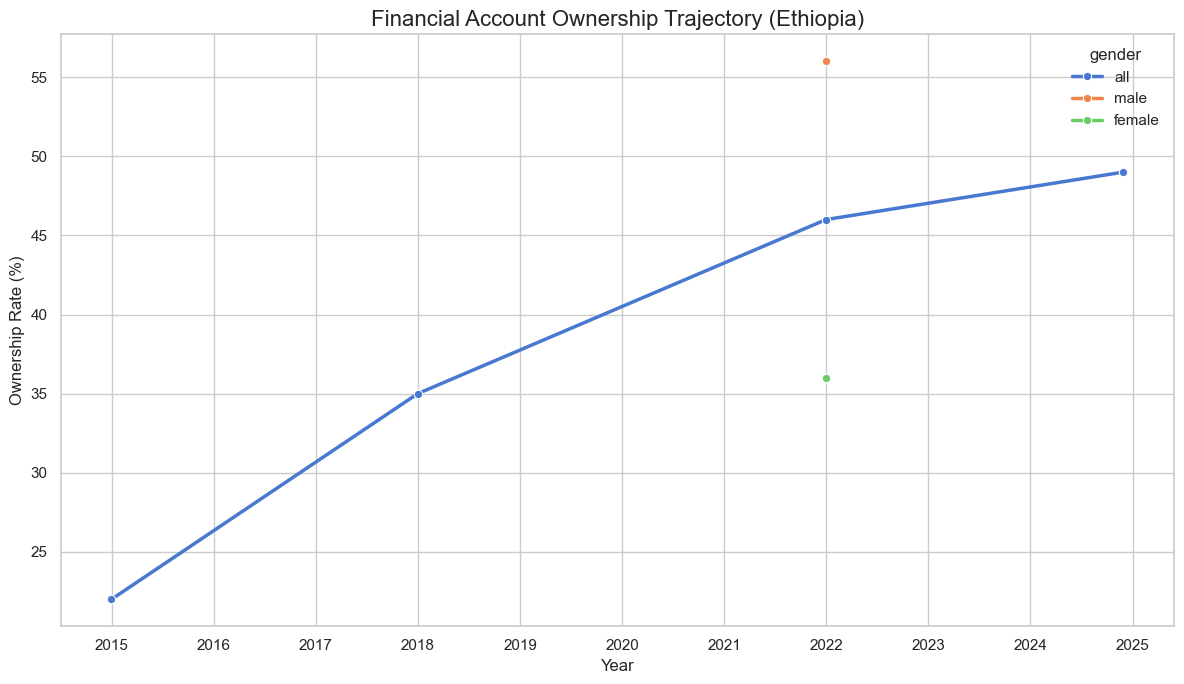

2026-02-02 11:37:39,867 - visualization_suite - INFO - Saved ownership plot to output\plots\account_ownership_trend.png


c:\GitHub\Forecasting-Financial-Inclusion-in-Ethiopia\src\visualization_suite.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=labels, y=values, palette="viridis")


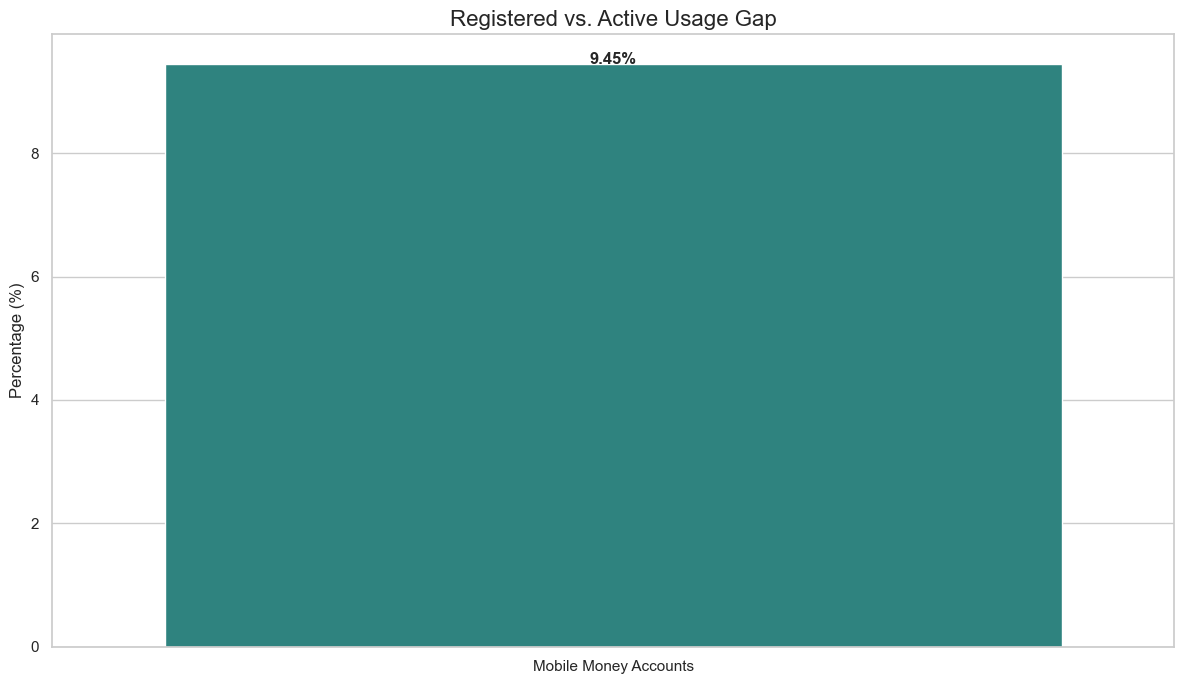

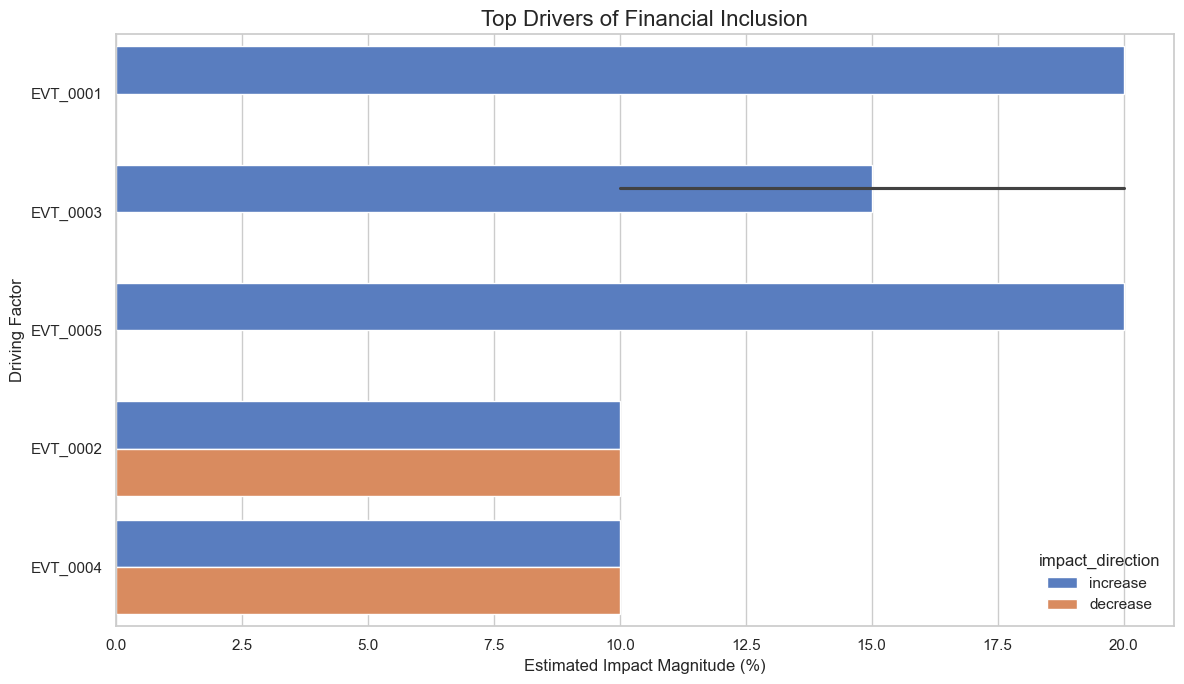

c:\GitHub\Forecasting-Financial-Inclusion-in-Ethiopia\src\visualization_suite.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=metrics, x='indicator', y='value_numeric', palette='flare')


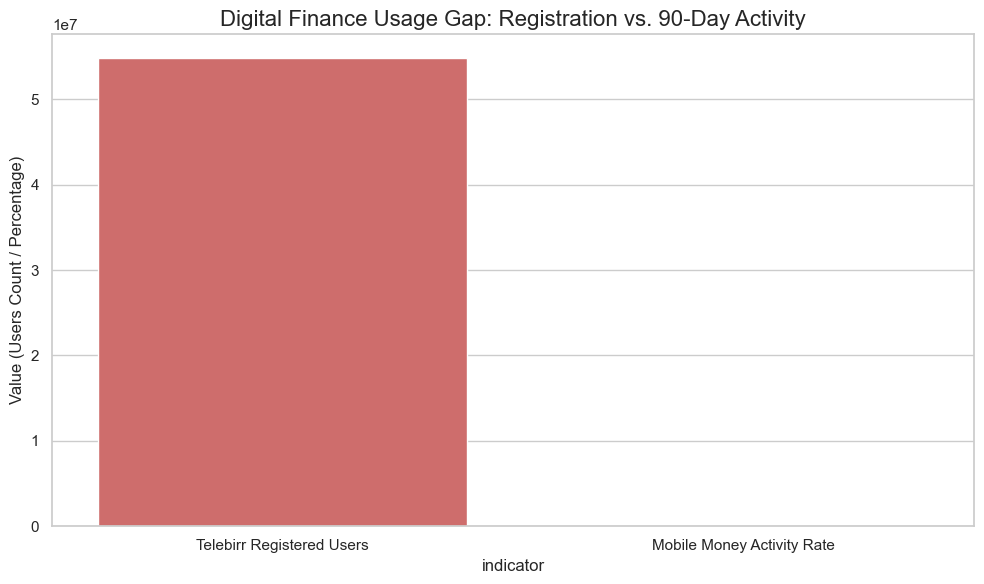

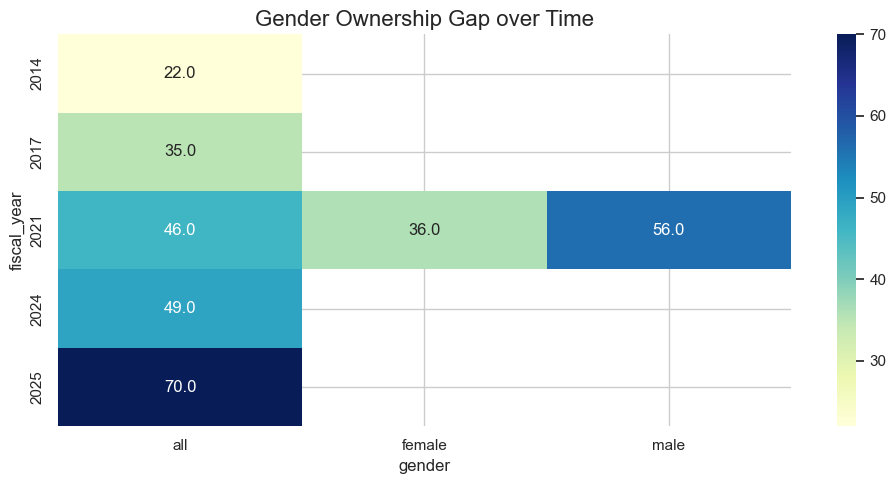

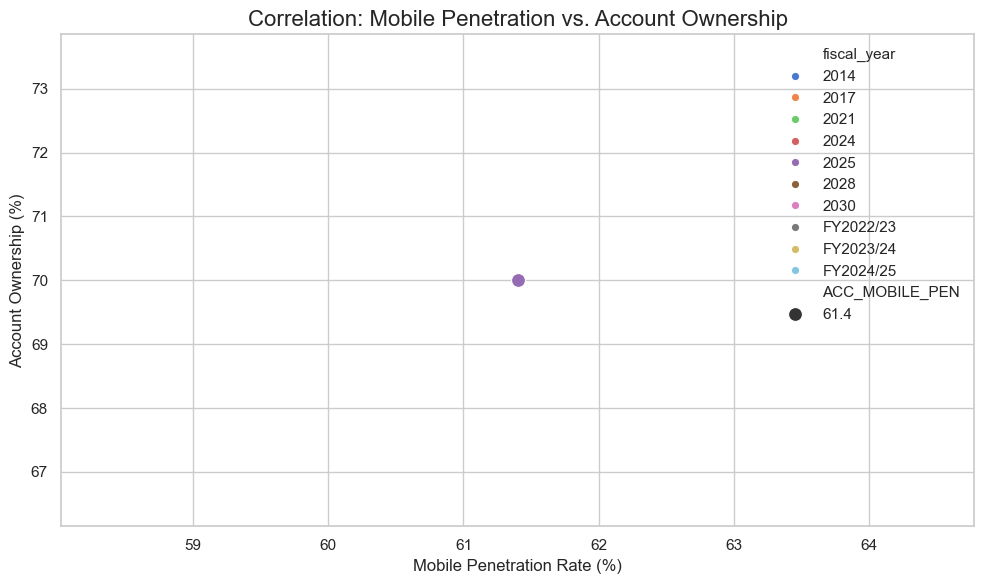

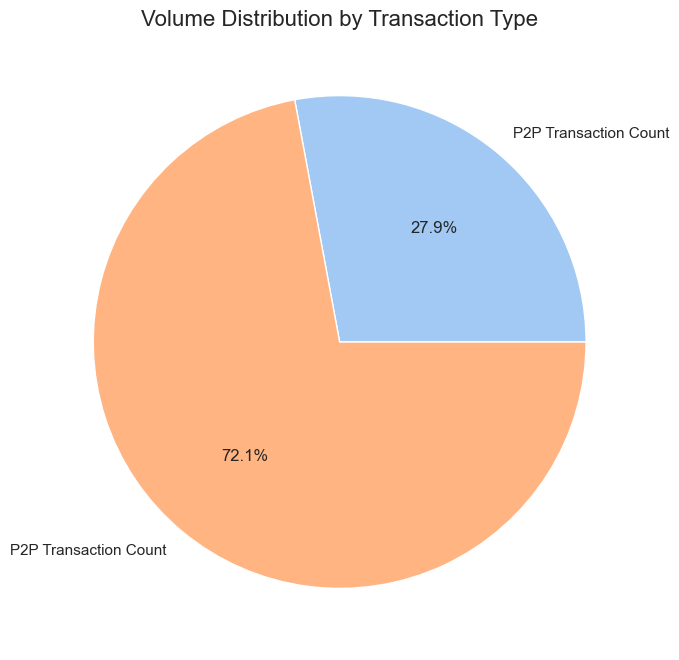

In [11]:
from visualization_suite import DataVisualizer

# 1. Run Analysis
access = ownership_data
usage_gap_temp = usage_gap
impacts = impact_relationships

# 2. Generate Plots
viz = DataVisualizer(output_dir='./output/plots')
viz.plot_ownership_trajectory(access)
viz.plot_usage_gap(usage_gap_temp)
viz.plot_impact_magnitudes(impacts)
viz.plot_usage_gap_bar(df)
viz.plot_gender_ownership_heatmap(df)
viz.plot_infra_vs_ownership_scatter(df)
viz.plot_transaction_type_pie(df)